## Exercise 3 — **Volcanic bomb**

The goal of this exercise is to consolidate:
- code structure `# Physics, # Numerics, # Time loop, # Visualisation`
- array initialisation
- update rule
- `if` condition

You will now simulate the trajectory of a [volcanic bomb](https://en.wikipedia.org/wiki/Volcanic_bomb) that got ejected during a volcanic eruption. The ejection speed is given by the horizontal and vertical velocity components
$$
V_x = \frac{\partial x}{\partial t}\\[10pt]
V_y = \frac{\partial y}{\partial t}
$$

Once ejected, the volcanic bomb is subject to gravity acceleration $g$. Air friction will be neglected. Acceleration being defined as the change of velocity over time, we obtain the following update rule:
$$
\frac{\partial V_y}{\partial t}=-g
$$

These equations define a mathematical model describing the kinematics of the volcanic bomb. You may remember from your studies how to solve those equation analytically; however we'll here focus on a numerical solution using a similar approach as for the previous exercises. The $x$ and $y$ location of the bomb as function of time can be obtained based on updating previous values using the definition of velocity:
$$
x_{t+\Delta t} = x_{t} + V_x    \Delta t~,\\[5pt]
y_{t+\Delta t} = y_{t} + V_y(t) \Delta t~.
$$
And because of gravity acceleration, the $V_y$ velocity evolution can be obtained according to
$$
V_{y,t+\Delta t} = V_{y,t} - g \Delta t~.
$$

The 3 equations above represent the discretised form of the 3 first equations and should be used to solve the problem numerically. The initial position of the volcanic bomb $(x_0, y_0)=(0,480)$ m. The magnitude of the ejection speed is of 120 m/s and the angle $\alpha = 60°$. The simulation stops when the volcanic bomb touches the ground ($y=0$).

> 💡 hint:
> - Modify the code from exercise 2 to, in addition, account for the change of `Vy` with time
> - Use e.g. a `break` statement to exit the loop once the bomb hits the ground

### Question 1

Report the height of the volcanic bomb at position $x=900$ m away from origin.

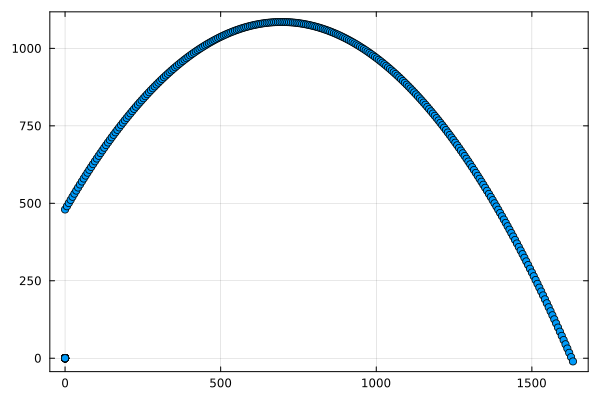

In [15]:
using Plots

@views function volcanic_bomb()
    x_0 = [0, 480]
    V = [cos(60 * π / 180), sin(60 * π / 180)] .* 120

    dt = 0.1
    nt = 1000
    
    X = zeros(2, nt)
    X[:,1] = x_0

    for it in 2:nt
        X[:,it] = X[:,it-1] + V * dt
        V[2] -= 9 * dt
        if X[2,it] <= 0
            break
        end
    end
    
    display(scatter(X[1,:], X[2,:], framestyle=:box, legend=:none))
    return
end

volcanic_bomb()